In [1]:
import lexos
lexos.__version__

'0.1.0'

## Table of Contents
1. Introduction
2. Setup and Imports
3. Creating a Basic Word Cloud
4. Customizing with `opts` and `figure_opts`
5. Using Frequency Dictionaries
6. Word Clouds from spaCy `Doc`
7. Removing Stop Words
8. Word Clouds from List of Token Lists
9. Word Cloud from Real Document
10. DTM Input with `docs` Filtering
11. Multicloud Grid Visualization
12. Handling Errors with `LexosException`
13. Developer Notes & Tips


# Lexos Word Cloud Tutorial

This tutorial demonstrates how to create stunning word clouds using the Lexos library. We'll cover both single word clouds and multiple word clouds (multiclouds) with various data input types and customization options.

## Installation and Setup






## Importing Necessary Libraries and Functions

**Purpose:**  
Load core Python libraries for data handling, file paths, and visualization functions from Lexos.


### Inputs

None

### Outputs

Makes the following names available in this notebook session:

* `pd` (pandas)
* `np` (numpy)
* `Path` (for filesystem paths)
* `wordcloud`, `multicloud` (functions for generating word clouds)
* `DTM` (Document-Term Matrix class)
* `Counter` (frequency counting)
* `plt` (matplotlib plotting)

### Explanation

This cell imports:

* `pandas` and `numpy` for data-frame manipulation and numerical operations.
* `Path` from `pathlib` to handle filesystem paths in a cross-platform way.
* `wordcloud` and `multicloud` from `lexos.visualization.cloud` to generate single or multiple word clouds.
* `DTM` from `lexos.dtm` in case you want to use Document-Term Matrices later on.
* `Counter` from `collections` to easily count term frequencies if needed.
* `matplotlib.pyplot` as `plt` to display or save generated plots.

```
```


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from lexos.visualization.cloud import wordcloud, multicloud
from lexos.dtm import DTM

# For demonstration purposes, we'll also import some sample data processing tools
from collections import Counter
import matplotlib.pyplot as plt


## Creating a Basic Word Cloud from Raw Text

**Purpose:**  
Demonstrate how to generate a simple word cloud directly from a multiline string.



### Inputs

* `sample_text` (str): A multiline string containing a short paragraph about NLP.

### Outputs

* Renders and displays a basic word cloud visualization of the words in `sample_text`. Common words appear larger according to frequency.

### Explanation

This cell defines `sample_text` as a Python triple-quoted string describing NLP. When you call `wordcloud(sample_text)`, the function tokenizes the text, counts word frequencies, and then renders a word cloud plot showing each term’s relative prominence.

```
```


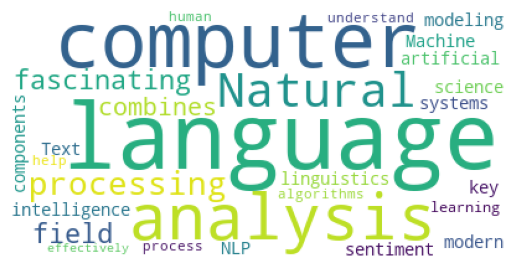

In [ ]:

sample_text = """
Natural language processing is a fascinating field that combines linguistics,
computer science, and artificial intelligence. Text analysis, sentiment analysis,
and language modeling are key components of modern NLP systems. Machine learning
algorithms help computers understand and process human language effectively.
"""

# Create a basic word cloud
wordcloud(sample_text)


## Defining Custom Styling Options for a Word Cloud

**Purpose:**  
Show how to customize the appearance of a word cloud using an options dictionary.



### Inputs

* `sample_text` (str): The same multiline NLP description string from the previous cell.
* `custom_opts` (dict): A dictionary specifying styling parameters for the word cloud:

  * `"background_color"`: Color of the plot background ("black").
  * `"colormap"`: Color scheme used for words ("viridis").
  * `"max_words"`: Maximum number of words to display (100).
  * `"contour_color"` / `"contour_width"`: Draws a contour around the cloud in white with width 1.
  * `"width"` / `"height"`: Pixel dimensions of the word cloud (800×400).
* `figure_opts` (dict): A dictionary for Matplotlib figure settings; here, `{"figsize": (12, 6)}` sets an overall figure size of 12×6 inches.

### Outputs

* Renders and displays a styled word cloud with the specified colors, maximum word count, contours, and figure dimensions.

### Explanation

By passing `opts=custom_opts`, you override default styling (white background, default colormap, etc.) and make a high-contrast word cloud. The `figure_opts` dictionary ensures that the final Matplotlib figure is sized appropriately.

```
```


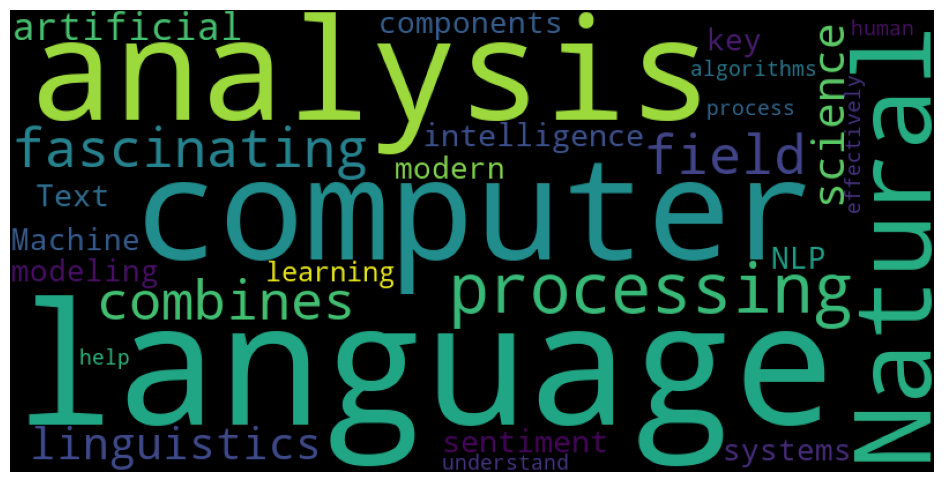

In [ ]:
# Custom styling options
custom_opts = {
    "background_color": "black",
    "colormap": "viridis",
    "max_words": 100,
    "contour_width": 2,
    "contour_color": "white",
    "width": 800,
    "height": 400
}

# Create a styled word cloud
wordcloud(
    sample_text,
    opts=custom_opts,
    figure_opts={"figsize": (12, 6)}
)


## Generating a Word Cloud from a Frequency Dictionary

**Purpose:**  
Show how to generate a word cloud directly from a term-frequency dictionary.


### Inputs

* `word_frequencies` (dict): A mapping of terms (keys) to integer frequencies (values).

### Outputs

* Renders and displays a word cloud where each term’s size is proportional to its count in `word_frequencies`. Words appear in the “plasma” colormap on a white background.

### Explanation

When you pass a dictionary instead of raw text, `wordcloud` uses the frequencies provided rather than computing them. This is useful when you already have term counts (e.g., from a DataFrame or custom counting method).

```
```


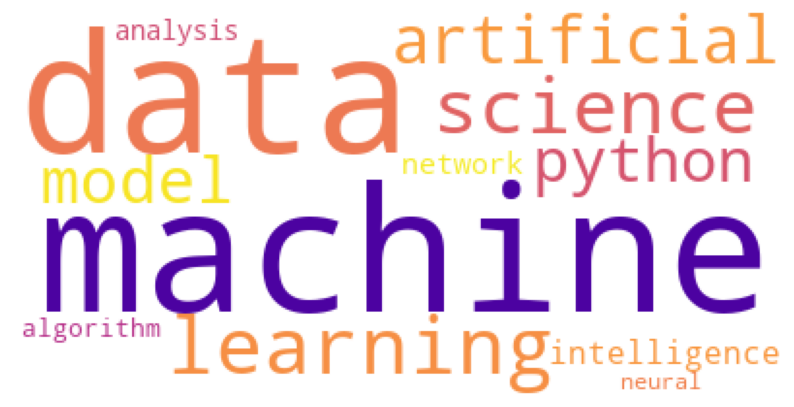

In [5]:
# Sample word frequency data
word_frequencies = {
    "machine": 25,
    "learning": 20,
    "artificial": 18,
    "intelligence": 15,
    "data": 22,
    "science": 19,
    "algorithm": 12,
    "neural": 10,
    "network": 14,
    "python": 16,
    "analysis": 13,
    "model": 17
}

# Create word cloud from frequencies
wordcloud(
    word_frequencies,
    opts={"background_color": "white", "colormap": "plasma"},
    figure_opts={"figsize": (10, 6)}
)


## Creating a Circular Word Cloud

**Purpose:**  
Illustrate how to force the word cloud to be roughly circular in shape.


### Inputs

* `sample_text` (str): The same NLP paragraph.
* `opts` (dict):

  * `"background_color": "navy"`
  * `"colormap": "cool"`
  * `"max_words": 150`
* `round` (int): Controls how circular the mask is. A higher value (`120`) makes it more circular.
* `figure_opts` (dict): `{"figsize": (8, 8)}` to produce an 8×8 inch square figure.

### Outputs

* Renders a circular/oval word cloud on a navy background with “cool” colormap.

### Explanation

The `round` argument instructs the underlying `wordcloud` generator to use a circular mask of the specified radius. By combining that with styling options, you get a neat circular arrangement of words.

```
```


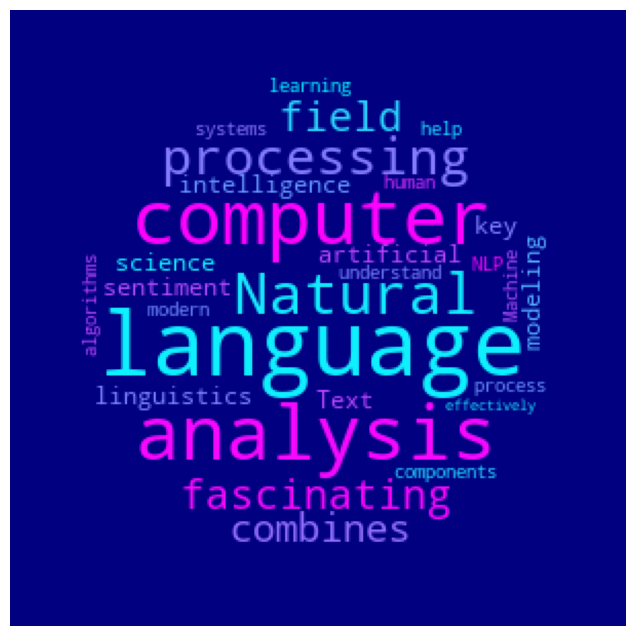

In [6]:
# Create a circular word cloud
wordcloud(
    sample_text,
    opts={
        "background_color": "navy",
        "colormap": "cool",
        "max_words": 150
    },
    round=120,  # Controls the roundness (100-300 works well)
    figure_opts={"figsize": (8, 8)}
)


## Generating a Word Cloud from a DataFrame

**Purpose:**  
Demonstrate how to generate a word cloud from a pandas DataFrame that holds term counts across multiple documents.


### Inputs

* `df` (pandas.DataFrame):

  * Index (terms): `"python"`, `"code"`, `"data"`, `"analysis"`, `"visualization"`, `"cloud"`, `"machine"`, `"learning"`, `"nlp"`
  * Columns (documents): `"doc1"`, `"doc2"`, `"doc3"`
  * Cell values: Term frequency counts for each document
* `opts` (dict):

  * `"colormap": "Set2"`
* `figure_opts` (dict): `{"figsize": (12, 6)}`

### Outputs

* Prints the DataFrame to the console.
* Renders a combined word cloud using cumulative frequencies from all columns. Words appear in the “Set2” palette on the default white background.

### Explanation

`wordcloud(df)` automatically sums term frequencies across all columns to build a single global frequency distribution. The DataFrame approach is useful when you already have structured term-document data from a corpus or Document-Term Matrix (DTM).

```
```


Sample DataFrame:
           doc1  doc2  doc3
machine      15     8    12
learning     12    15    10
data         20    18    15
science       8    12    14
python       10    14     8
analysis      6    10    12
model         9    11    13
algorithm     7     5     9


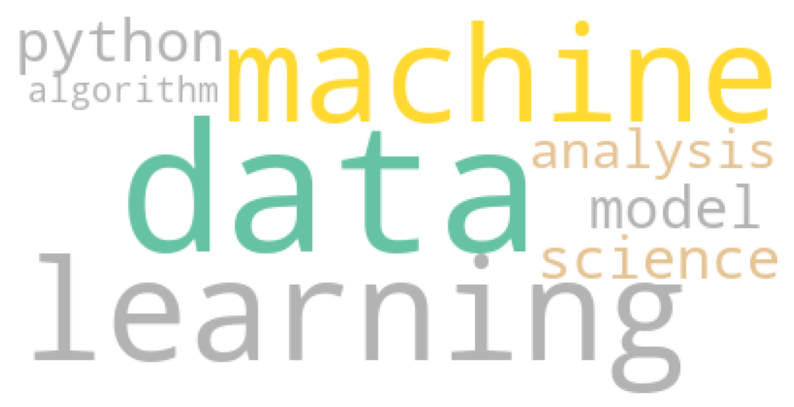

In [7]:

terms = ["machine", "learning", "data", "science", "python", "analysis", "model", "algorithm"]
doc_data = {
    "doc1": [15, 12, 20, 8, 10, 6, 9, 7],
    "doc2": [8, 15, 18, 12, 14, 10, 11, 5],
    "doc3": [12, 10, 15, 14, 8, 12, 13, 9]
}

df = pd.DataFrame(doc_data, index=terms)
print("Sample DataFrame:")
print(df)

# Create word cloud from DataFrame (combines all documents)
wordcloud(
    df,
    opts={"background_color": "white", "colormap": "Set2"},
    figure_opts={"figsize": (10, 6)}
)


## Saving a Word Cloud to Disk

**Purpose:**  
Show how to create a word cloud and save it as an image file.

### Inputs

* `sample_text` (str): Raw text to visualize.
* `opts` (dict):

  * `"background_color": "white"`
  * `"colormap": "viridis"`
  * `"max_words": 100`
* `path` (str): Filename (relative or absolute) where the word-cloud image will be saved.

### Outputs

* Saves `my_wordcloud.png` to the working directory.
* Prints a confirmation message to the console.

### Explanation

By adding the `path` argument, `wordcloud` writes the generated figure out as a PNG file rather than opening a popup. This is helpful if you want to use the image in reports or presentations.

```
```


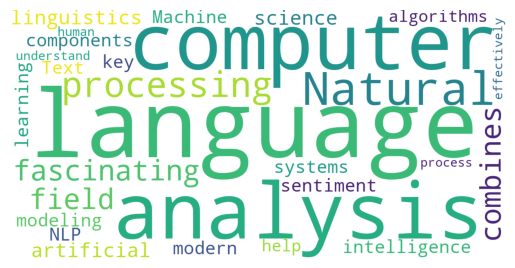

Word cloud saved as 'my_wordcloud.png'


In [8]:
# Create and save a word cloud
wordcloud(
    sample_text,
    opts={
        "background_color": "white",
        "colormap": "viridis",
        "width": 1200,
        "height": 600
    },
    path="my_wordcloud.png"  # Will save to current directory
)
print("Word cloud saved as 'my_wordcloud.png'")


## Creating and Inspecting a Word Cloud without Displaying It

**Purpose:**  
Generate a word cloud object in code, inspect its properties, save it manually, and then display it with `matplotlib` instead of letting `wordcloud` auto-show it.


### Inputs

* `sample_text` (str): The same NLP sample text.
* `show` (bool): Set to `False` so that the function returns the underlying `WordCloud` object instead of plotting it.

### Outputs

* `wc` (WordCloud object): The in-memory representation of the word cloud.
* Prints width, height, and total number of words in the cloud to console.
* Saves `custom_wordcloud.png` to disk.
* Reads and displays that saved image using Matplotlib.

### Explanation

Calling `wordcloud(..., show=False)` returns the raw `WordCloud` object. You can then inspect attributes like `.width` (pixel width), `.height` (pixel height), and `.words_` (a dict of word-to-frequency mapping). Finally, `wc.to_file(...)` writes the PNG, and we use `plt` to load and display it manually. This workflow is useful when you want programmatic control over saving and later displaying.

```
```


Word cloud dimensions: 400 x 200
Number of words: 12


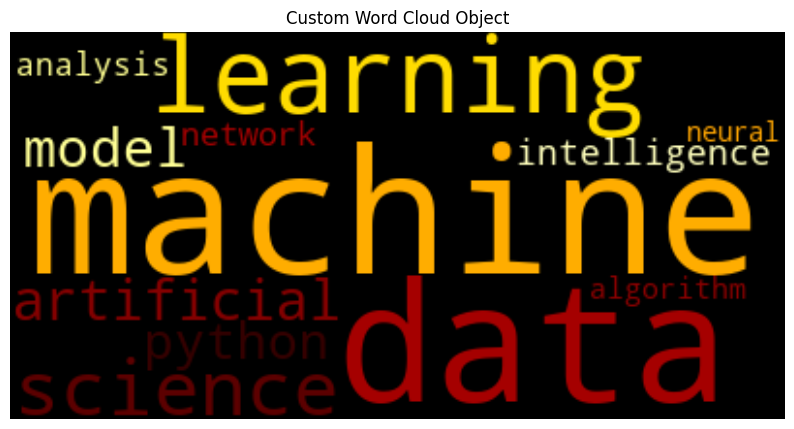

In [9]:
# Get WordCloud object instead of displaying
wc_object = wordcloud(
    word_frequencies,
    opts={"background_color": "black", "colormap": "hot"},
    show=False
)

# Now you can manipulate the object
print(f"Word cloud dimensions: {wc_object.width} x {wc_object.height}")
print(f"Number of words: {len(wc_object.words_)}")

# Save using the object's method
wc_object.to_file("custom_wordcloud.png")

# Display it manually
plt.figure(figsize=(10, 6))
plt.imshow(wc_object, interpolation='bilinear')
plt.axis('off')
plt.title("Custom Word Cloud Object")
plt.show()

### Multicloud Visualization (Grid of Word Clouds)

Lexos provides a `multicloud()` function that lets you visualize multiple documents as a grid of word clouds. This is especially useful when comparing text patterns across different documents.

The `multicloud()` function accepts the same input types as `wordcloud()` (including DTM, list of strings, etc.), and supports additional options such as:
- `ncols`: number of columns in the grid
- `labels`: list of document titles
- `title`: overall figure title
- `show`: display or return word clouds
- `round`: optional mask for circular clouds

Below, we visualize 4 short text snippets using this function.


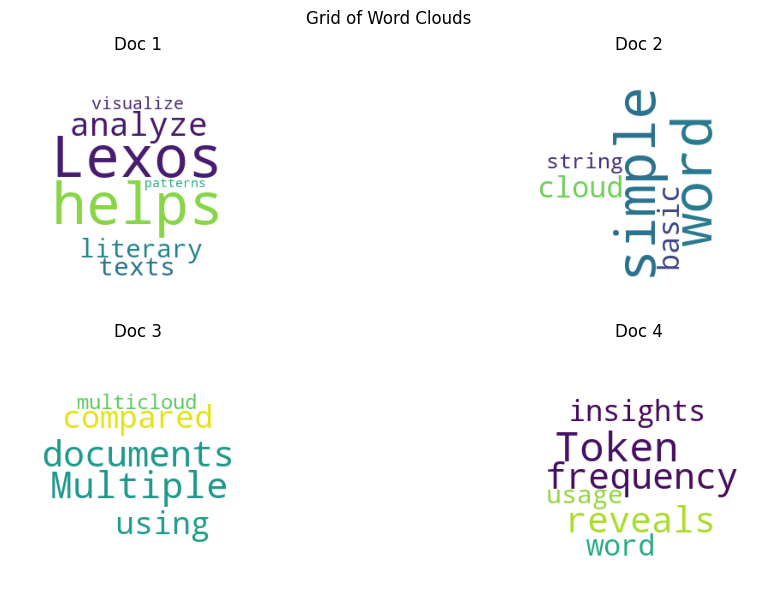

In [14]:
from lexos.visualization.cloud import multicloud

# Sample multiple documents
docs = [
    "Lexos helps analyze literary texts and visualize patterns.",
    "This is a simple word cloud from a basic string.",
    "Multiple documents can be compared using multicloud.",
    "Token frequency reveals insights about word usage."
]

# Plot multicloud
multicloud(
    data=docs,
    ncols=2,
    labels=["Doc 1", "Doc 2", "Doc 3", "Doc 4"],
    title="Grid of Word Clouds",
    round=120,
    figure_opts={"figsize": (10, 6)}
)


### Handling Invalid Input: LexosException

The `wordcloud()` function raises a `LexosException` if the input type is unsupported or inconsistent (e.g., mixing strings and `Doc` objects in one list).

This helps developers catch format mismatches early. Below is an example where we intentionally pass mixed input types to trigger the error.


In [17]:
from spacy.lang.en import English
nlp = English()
doc = nlp("This is a spaCy doc.")

# This will trigger LexosException due to mixed types
try:
    wordcloud(["text string", doc])
except Exception as e:
    print("Caught an error:", e)


Caught an error: 20 validation errors for wordcloud
0.dict[str,int]
  Input should be a valid dictionary [type=dict_type, input_value=['text string', This is a spaCy doc.], input_type=list]
    For further information visit https://errors.pydantic.dev/2.11/v/dict_type
0.is-instance[Doc]
  Input should be an instance of Doc [type=is_instance_of, input_value=['text string', This is a spaCy doc.], input_type=list]
    For further information visit https://errors.pydantic.dev/2.11/v/is_instance_of
0.is-instance[Span]
  Input should be an instance of Span [type=is_instance_of, input_value=['text string', This is a spaCy doc.], input_type=list]
    For further information visit https://errors.pydantic.dev/2.11/v/is_instance_of
0.str
  Input should be a valid string [type=string_type, input_value=['text string', This is a spaCy doc.], input_type=list]
    For further information visit https://errors.pydantic.dev/2.11/v/string_type
0.list[str].1
  Input should be a valid string [type=string_ty

### Word Cloud from List of Token Lists

Lexos supports word cloud generation from a `list[list[str]]`, where each inner list represents a document as a list of tokens.

This format is common in pre-tokenized datasets or NLP pipelines. Here's a basic example with three tokenized documents.


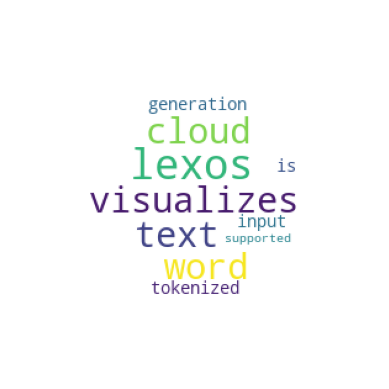

In [18]:
docs_as_tokens = [
    ["lexos", "visualizes", "text"],
    ["word", "cloud", "generation"],
    ["tokenized", "input", "is", "supported"]
]

wordcloud(docs_as_tokens, docs=0, round=90)  # Visualize just the first document


### Word Cloud from Real Text (spaCy Doc Input)

Lexos supports input in the form of `spaCy` Doc objects. This allows for cleaner tokenization, filtering, and better control over text analysis.

Here, we:
1. Load a `.txt` file (e.g., a novel)
2. Use `spaCy` to convert the text into a `Doc`
3. Pass the `Doc` directly to `wordcloud()`


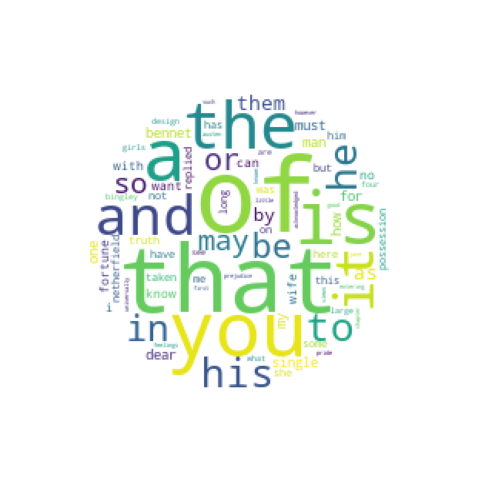

In [ ]:
import spacy
from pathlib import Path
from collections import Counter
from lexos.visualization.cloud import wordcloud

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Load and slice real document
text = Path("docs/Austen_Pride.txt").read_text(encoding="utf-8")
doc = nlp(text[:2000])

# Clean tokens: remove punctuation, spaces, and non-alpha tokens
tokens = [
    token.text.lower()
    for token in doc
    if not token.is_punct and not token.is_space and token.is_alpha
]

# Convert to frequency dictionary
counts = dict(Counter(tokens))

# Now plot using the frequency dictionary
wordcloud(counts, round=100, figure_opts={"figsize": (6, 6)})


###  Removing Stop Words from Real Documents

When working with real-world text, it's important to remove common "stop words" such as *the*, *and*, *of*, etc., which do not carry meaningful information in most analyses.

In this example:
1. We load a real `.txt` file (*Pride and Prejudice*).
2. We use `spaCy` to tokenize the text and extract only relevant tokens.
3. We filter out:
   - Stop words (using `token.is_stop`)
   - Punctuation (`token.is_punct`)
   - Whitespace (`token.is_space`)
   - Non-alphabetic characters (`token.is_alpha`)
4. We count the frequency of remaining tokens and pass them into `wordcloud()`.

This produces a cleaner, more meaningful word cloud that highlights **key thematic words** from the text while ignoring grammatical noise.


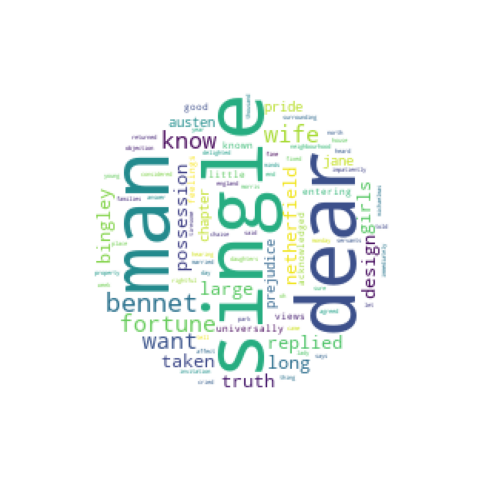

In [ ]:
import spacy
from pathlib import Path
from collections import Counter
from lexos.visualization.cloud import wordcloud

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Load and slice real document
text = Path("docs/Austen_Pride.txt").read_text(encoding="utf-8")
doc = nlp(text[:2000])

# Clean tokens: remove stop words, punctuation, spaces, and non-alpha
tokens = [
    token.text.lower()
    for token in doc
    if not token.is_stop and not token.is_punct and not token.is_space and token.is_alpha
]

# Convert to frequency dictionary
counts = dict(Counter(tokens))

# Generate word cloud from cleaned and filtered tokens
wordcloud(counts, round=100, figure_opts={"figsize": (6, 6)})


### Multicloud from a Real Document (Cleaned + Sliced)

Lexos's `multicloud()` function allows us to visualize **multiple documents or text slices** in a grid of word clouds. This is particularly useful for comparing different sections of a single long document — such as the beginning, middle, and end of a novel — or multiple short texts.

In this example, we:
1. Load the full text of *Pride and Prejudice* from a `.txt` file.
2. Slice the text into three equal-length chunks.
3. Use `spaCy` to tokenize each chunk and clean the tokens by removing:
   - Stop words (e.g., "the", "is", "of")
   - Punctuation
   - Whitespace
   - Non-alphabetic tokens
4. Pass the resulting list of token lists (`list[list[str]]`) to `multicloud()`.

We also add:
- A **rounded mask** (`round=120`) for visual styling.
- Custom **labels** ("Beginning", "Middle", "End").
- A **figure title** and `figsize` to control layout.



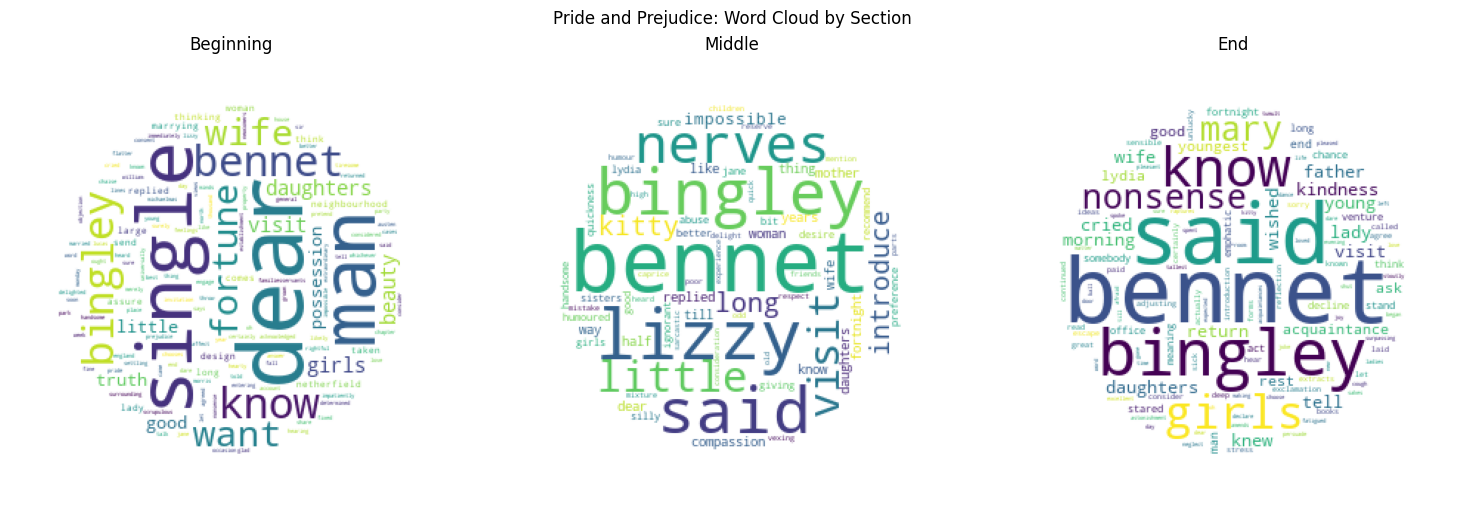

In [ ]:
import spacy
from pathlib import Path
from lexos.visualization.cloud import multicloud

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Load full text
text = Path("docs/Austen_Pride.txt").read_text(encoding="utf-8")

# Split into 3 chunks
slices = [text[:3000], text[3000:6000], text[6000:9000]]

# Tokenize and clean each chunk into list[list[str]]
token_lists = []
for chunk in slices:
    doc = nlp(chunk)
    tokens = [
        token.text.lower()
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space and token.is_alpha
    ]
    token_lists.append(tokens)

# Pass token lists directly into multicloud
multicloud(
    data=token_lists,
    labels=["Beginning", "Middle", "End"],
    ncols=3,
    round=120,
    title="Pride and Prejudice: Word Cloud by Section",
    figure_opts={"figsize": (15, 5)}
)


## 💡 Developer Notes

- The `wordcloud()` and `multicloud()` functions support many input types:
  - Strings, Lists of tokens, `spaCy` Docs/Spans
  - Dicts of term:freq, Pandas DataFrames, Lexos DTM
- Optional arguments like `opts`, `figure_opts`, and `round` allow rich customization.
- Use `docs=[...]` to subset a DTM or multi-doc structure.
- Errors like `LexosException` will occur if input types are inconsistent or mixed.
- To suppress display and return the `WordCloud` object, set `show=False`.
